# Image preprocessing


In [1]:
import os
import cv2
import numpy as np
import math

# Seperate to words

C:\Users\ltzai\Anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


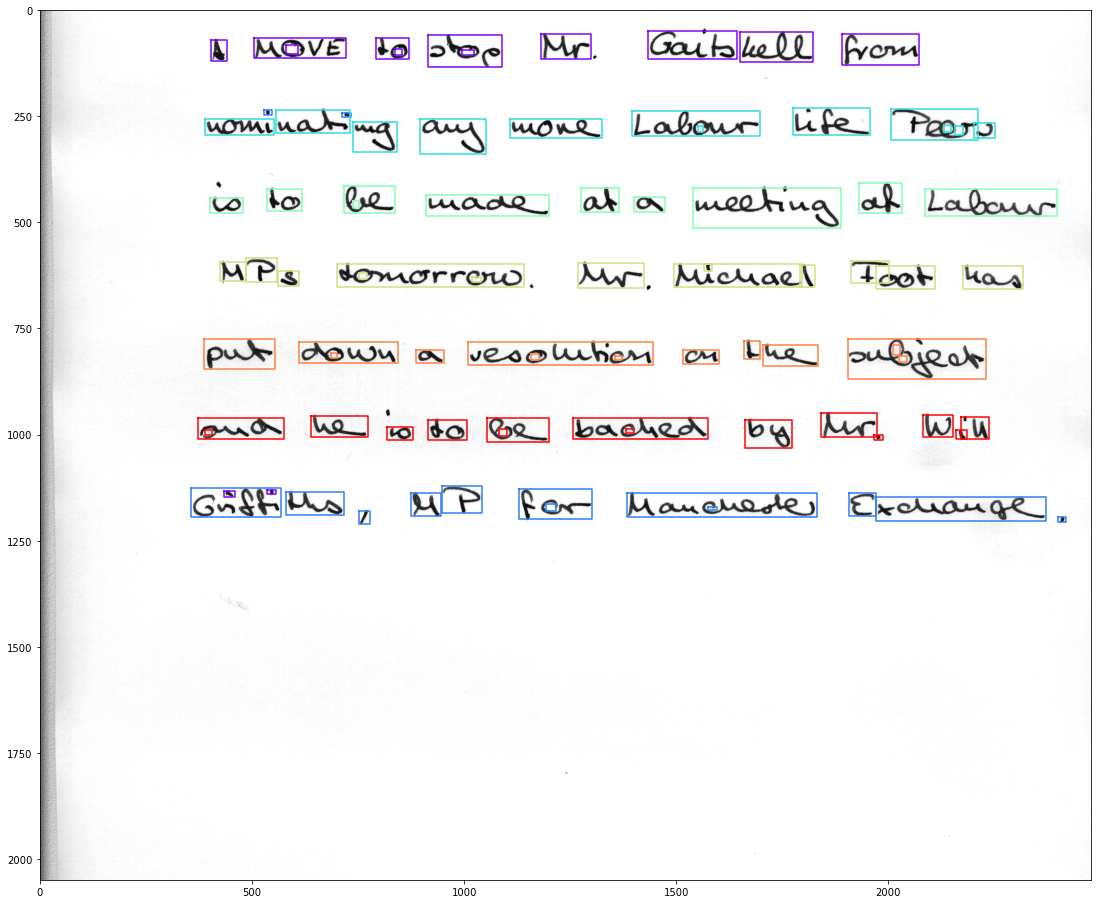

In [2]:
from word_detector import prepare_img, detect, sort_line,sort_multiline
import matplotlib.pyplot as plt
import cv2

# (1) prepare image:
# (1a) convert to grayscale
# (1b) scale to specified height because algorithm is not scale-invariant
image = cv2.imread("handwritten_data//a01-000u.png")
image = image[700:2750, ]
img = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)


# (2) detect words in image
detections = detect(img,
                    kernel_size=25,
                    sigma=11,
                    theta=7,
                    min_area=100)

# (3) sort words in line
lines = sort_multiline(detections)

# plot results
plt.figure(figsize=(20,16))
plt.imshow(img, cmap='gray')
num_colors = 7
words_list = []
colors = plt.cm.get_cmap('rainbow', num_colors)
for line_idx, line in enumerate(lines):
    for word_idx, det in enumerate(line):
        xs = [det.bbox.x, det.bbox.x, det.bbox.x + det.bbox.w, det.bbox.x + det.bbox.w, det.bbox.x]
        ys = [det.bbox.y, det.bbox.y + det.bbox.h, det.bbox.y + det.bbox.h, det.bbox.y, det.bbox.y]
        plt.plot(xs, ys, c=colors(line_idx % num_colors))
        words_list.append([det.bbox.x, det.bbox.y, det.bbox.x + det.bbox.w, det.bbox.y + det.bbox.h])
        #plt.text(det.bbox.x, det.bbox.y, f'{line_idx}/{word_idx}')
plt.show()

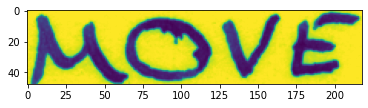

In [3]:
sp_word = words_list[2]
roi = img[sp_word[1]:sp_word[3], sp_word[0]:sp_word[2]]
plt.imshow(roi);

## save all the words in file words_in_image

In [4]:
for word_idx, word in enumerate(words_list, start=-len(words_list)):
    roi = image[word[1]:word[3], word[0]:word[2]]
    #roi = cv2.copyMakeBorder(roi, 100, 100, 100, 100,borderType=0, value = (255,255,255))
    cv2.imwrite('words_in_image//word'+str(word_idx)+'.png',roi)

# Contour detection

### binarization

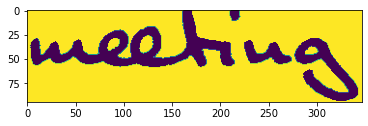

In [5]:
from skimage import io, color, morphology
from imutils import contours

image = cv2.imread('words_in_image//word-58.png')
#image = cv2.resize(image, (128,72))
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
#blurred = cv2.GaussianBlur(gray, (7, 7), 0)
(T, threshInv) = cv2.threshold(gray, 230, 255,cv2.THRESH_BINARY_INV)
threshInv = cv2.subtract(255, threshInv) 
plt.imshow(threshInv)
#cv2.imwrite('binarizations.png',threshInv)

### skelotonizations

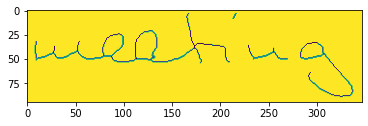

In [6]:
out_skeletonize = morphology.skeletonize(threshInv < 0.5) #sceletonize binarize
skeletonize = cv2.subtract(255, out_skeletonize*255)
skeletonize = skeletonize.astype(np.uint8)
#cv2.imwrite('skelotonizations.png',skeletonize)
plt.imshow(skeletonize)

### Countours

In [7]:
def sort_contours(cnts, method="left-to-right"):
    # initialize the reverse flag and sort index
    reverse = False
    i = 0
    # handle if we need to sort in reverse
    if method == "right-to-left" or method == "bottom-to-top":
        reverse = True
    # handle if we are sorting against the y-coordinate rather than
    # the x-coordinate of the bounding box
    if method == "top-to-bottom" or method == "bottom-to-top":
        i = 1
    # construct the list of bounding boxes and sort them from top to
    # bottom
    boundingBoxes = [cv2.boundingRect(c) for c in cnts]
    (cnts, boundingBoxes) = zip(*sorted(zip(cnts, boundingBoxes),
        key=lambda b:b[1][i], reverse=reverse))
    # return the list of sorted contours and bounding boxes
    return (cnts, boundingBoxes)

Closed contours: 3


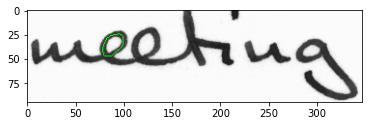

In [8]:
num = 0
cnts,hierarchy = cv2.findContours(cv2.subtract(1, skeletonize), cv2.RETR_TREE,cv2.CHAIN_APPROX_NONE)
#keep only countour inside the character
holes = [cnts[i] for i in range(len(cnts)) if hierarchy[0][i][3] >= 0]

try:
    (holes, _) = sort_contours(holes, method="left-to-right")
except:
    print('not inside contours')


closed_contours = []
open_contours = []
for i in holes:
    if cv2.contourArea(i) > cv2.arcLength(i, True):
        closed_contours.append(i)
    else:
        open_contours.append(i)
print('Closed contours: {}'.format(len(closed_contours)))

img = cv2.drawContours(image.copy(), [closed_contours[0]], 0, [0, 255, 0])
plt.imshow(img)
#cv2.imwrite("contour.png", img) 


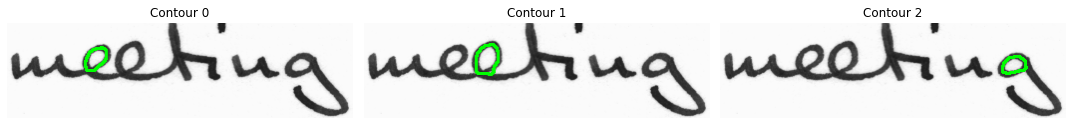

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for i in range(3):
    img = cv2.drawContours(image.copy(), [closed_contours[i]], 0, (0, 255, 0), 2)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axs[i].imshow(img_rgb)
    axs[i].set_title(f'Contour {i}')
    axs[i].axis('off')

plt.tight_layout()
plt.show()

# Surface size

In [10]:
cv2.contourArea(closed_contours[0])

342.5

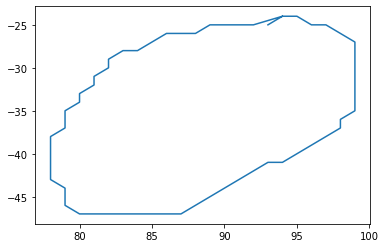

In [11]:
final_contour = closed_contours[0]
final_contour = np.vstack(final_contour).squeeze()
final_contour = np.vstack((final_contour, final_contour[1,]))
#final_contour = final_contour.reshape((final_contour.shape[0]*final_contour.shape[1]), final_contour.shape[2])
final_contour[:,1] = -final_contour[:,1]
plt.plot(final_contour[:,0],final_contour[:,1])
plt.show()

# Centrerize

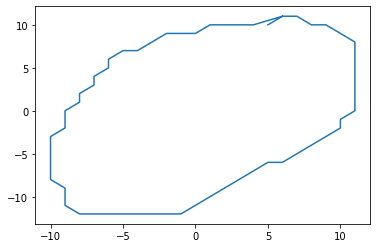

In [12]:
#Centrerize
M = cv2.moments(final_contour)
cx = int(M["m10"] / M["m00"])
cy = int(M["m01"] / M["m00"])


center_final_contour = final_contour[:] - np.array([cx,cy])
plt.plot(center_final_contour[:,0],center_final_contour[:,1])
plt.show()

# To polar coordinates

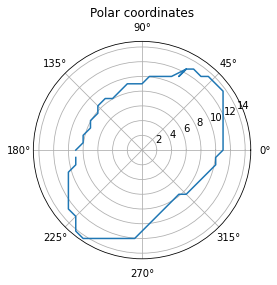

In [14]:
def cart2pol(x, y):
    rho = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    return (rho, phi)


polar = [cart2pol(c[0], c[1]) for c in center_final_contour[:]]
max_i = polar.index(max(polar, key = lambda x: x[1]))
polar = polar[max_i:] + polar[:max_i]
ds, phis = zip(*polar)
phis = np.array(phis)#[p + 2 * np.pi if p < 0 else p for p in phis]
ds = np.array(ds)

plt.polar (phis, ds)
plt.title ("Polar coordinates")
plt.show ()

# Fourier series

Fourier Coefficients:
a0: 10.78 a1: -0.56 b1: -0.45 a2: -1.25 b2: -2.23 a3: -0.29 b3: 0.44 a4: 0.08 b4: 0.13
Reconstruction:


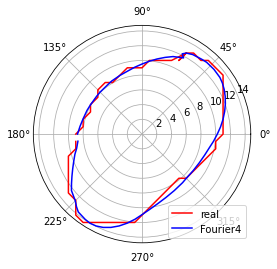

In [15]:
N = len(ds)
Y = np.fft.fft(ds)/N
#Y = np.concatenate((Y[:(N+1)//2], np.zeros(N), Y[(N+1)//2:])) #https://stackoverflow.com/questions/51182265/modeling-a-fourier-series-from-discrete-fourier-transform-for-extrapolation
Re = np.real(Y)
Im = np.imag(Y)

theta = np.linspace(0, 2*np.pi, N)

#n = np.arange(N)
#k = n.reshape((N, 1))
#t = 2* np.pi * k * n / N


rho=Re[0]
for i in range(1,5):
    an = 2*Re[i]
    bn = -2*Im[i]
    rho = rho +  an*np.cos(i*theta) +  bn*np.sin(i*theta)
    #rho = rho +  an*np.cos(t[i]) +  bn*np.sin(t[i])

print('Fourier Coefficients:')
print('a0:', round(Re[0],2), 'a1:',round(2*Re[1],2), 'b1:', round(-2*Im[1],2) ,'a2:', round(2*Re[2],2), 
      'b2:', round(-2*Im[2],2),'a3:', round(2*Re[3],2), 'b3:', round(-2*Im[3],2),
      'a4:', round(2*Re[4],2), 'b4:', round(-2*Im[4],2))

print('Reconstruction:')

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})

# Plot both curves on the same polar axes
ax.plot(phis, ds, c='r', label="real")
ax.plot(phis, rho, c='b', label="Fourier4")

ax.legend(loc='lower right')  # adjust location as needed
plt.show()

## Recostruction with 20 harmonics

Reconstruction:


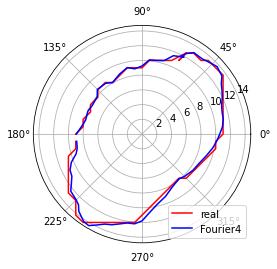

In [16]:
N = len(ds)
Y = np.fft.fft(ds)/N

Re = np.real(Y)
Im = np.imag(Y)

#theta = np.linspace(0, 2*np.pi, N)

N = len(Y)
n = np.arange(N)
k = n.reshape((N, 1))
t = 2* np.pi * k * n / N

harmonics = 20
rho = Re[0]
for i in range(1,harmonics+1):
    an = 2*Re[i]
    bn = -2*Im[i]
    rho = rho +  an*np.cos(i*theta) +  bn*np.sin(i*theta)
    #rho = rho +  an[i]*np.cos(i*theta) +  bn[i]*np.sin(i*theta)
    

print('Reconstruction:')

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})

# Plot both curves on the same polar axes
ax.plot(phis, ds, c='r', label="real")
ax.plot(phis, rho, c='b', label="Fourier4")

ax.legend(loc='lower right')  # adjust location as needed
plt.show()